<a href="https://colab.research.google.com/github/hitomitsu50/Sports_data_portfolio_MLB_Statcast/blob/main/2025%E5%B9%B4Statcast%E3%83%95%E3%82%A9%E3%83%BC%E3%82%B7%E3%83%BC%E3%83%A0%E5%9B%9E%E8%BB%A2%E6%95%B0TOP10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#ライブラリのインストール
!pip install pybaseball japanize_matplotlib
!sudo apt-get -y update
!sudo apt-get -y fonts-ipaexfont

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 41.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 426.1/426.1 kB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 432.7/432.7 kB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 65.1 MB/s eta 0:00:00
  Created wheel for japanize_matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=f65d01581b5252571a9ca1f36d3e3c74cdb0c0630fe4476b9bc101b65a58a202
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize_matplotlib
Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [83.8 kB]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Hit:5 http

In [ ]:
#ライブラリのインポート
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import japanize_matplotlib
import time
import glob
from pybaseball import statcast

In [ ]:
#データの読み込みと結合
#ファイル名パターンに一致するＣＳＶを取得
csv_files_pattern=("sample_data/statcast_*.csv")
csv_files=glob.glob(csv_files_pattern)

In [ ]:
#ＣＳＶファイルを読み込み データを格納
dfs=[]
for file in csv_files:
  try:
    df_month=pd.read_csv(file)
    dfs.append(df_month)
    print(f"{file}を読み込みました。")
  except Exception as e:
    print(f"{file}の読み込み中にエラーが発生:{e}")

sample_data/statcast_2025-03-18-2025-03-31.csvを読み込みました。
sample_data/statcast_2025-09-01-2025-09-28.csvを読み込みました。
sample_data/statcast_2025-05-01-2025-05-31.csvを読み込みました。
sample_data/statcast_2025-08-01-2025-08-31.csvを読み込みました。
sample_data/statcast_2025-04-01-2025-04-30.csvを読み込みました。
sample_data/statcast_2025-07-01-2025-07-31.csvを読み込みました。
sample_data/statcast_2025-06-01-2025-06-30.csvを読み込みました。


In [ ]:
#データの結合
if dfs:
  df_combined=pd.concat(dfs, ignore_index=True)
  df=df_combined #dfに格納
  print("全てのデータを結合しました。")
  display(df.head())
  print(f"結合後の行数{len(df)}")
else:
  print("csvファイルが見つかりませんでした。")

全てのデータを結合しました。


,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
0,SI,2025-03-31,96.6,0.22,7.01,"Bautista, Félix",608324,642585,field_out,hit_into_play,...,2.0,0.86,0.33,0.33,69.1,NaN,NaN,NaN,NaN,NaN
1,SL,2025-03-31,86.8,-0.50,6.78,"Bautista, Félix",608324,642585,NaN,ball,...,2.0,3.02,-0.52,-0.52,57.4,NaN,NaN,NaN,NaN,NaN
2,SI,2025-03-31,97.8,0.18,7.03,"Bautista, Félix",646240,642585,walk,ball,...,2.0,0.77,0.38,-0.38,68.6,NaN,NaN,NaN,NaN,NaN
3,SI,2025-03-31,97.8,0.18,6.95,"Bautista, Félix",646240,642585,NaN,foul,...,2.0,0.71,0.38,-0.38,73.1,2.326145,17.900737,28.548852,43.512056,18.085586
4,SI,2025-03-31,97.7,0.05,7.02,"Bautista, Félix",646240,642585,NaN,called_strike,...,2.0,0.59,0.39,-0.39,71.4,NaN,NaN,NaN,NaN,NaN


結合後の行数742080


In [ ]:
# --- 1. フォーシーム(FF)かつ 判定ボール(ball)以外を抽出 ---
strike_zone_results=["strike","swinging_strike","called_strike","foul","hit_into_play"]
df_4seam=df[(df["pitch_type"]=="FF")&(df["description"].isin(strike_zone_results))].copy()

In [ ]:
# --- 2. 投手ごとの集計(100球以上の投手に限定) ---
pitcher_spin=df_4seam.groupby("player_name").agg(
    Avg_Spin=("release_spin_rate","mean"),
    Pitch_Count=("release_spin_rate","count")
).reset_index()

MIN_PITCHERS=100
top_10_spin=pitcher_spin[pitcher_spin["Pitch_Count"]>=MIN_PITCHERS].sort_values(by="Avg_Spin",
                                                                                ascending=False).head(10)


In [ ]:
#--- 3. 姓 名 表示
def reformat_name(name):
  if "," in name:
    last,first=name.split(", ")
    return f"{first} {last}"
  return name
top_10_spin["player_name"]=top_10_spin["player_name"].apply(reformat_name)

/tmp/ipython-input-2968051668.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plot=sns.barplot(data=top_10_spin,x="Avg_Spin",y="player_name",palette="crest")


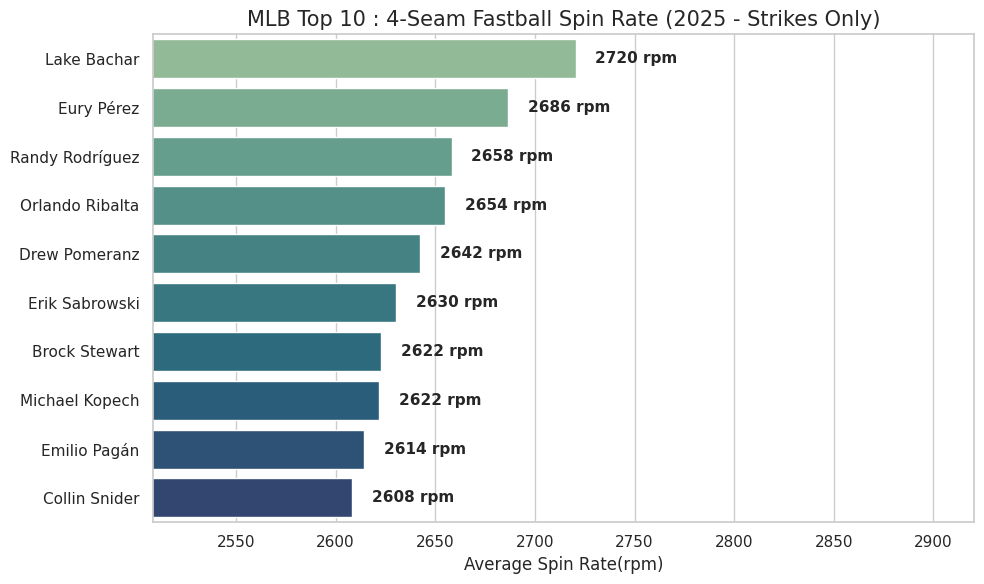

In [ ]:
# --- 4. 可視化（棒グラフ＆右側に単位表示）
plt.figure(figsize=(10,6))
sns.set_theme(style="whitegrid")
#配色
plot=sns.barplot(data=top_10_spin,x="Avg_Spin",y="player_name",palette="crest")
#数値と単位(rpm)を棒の右側に表示
for p in plot.patches:
  width=p.get_width()
  plot.text(width + 10, p.get_y() + p.get_height()/2, f"{int(width)} rpm",
            va="center",fontweight="bold",fontsize=11)
plt.title("MLB Top 10 : 4-Seam Fastball Spin Rate (2025 - Strikes Only)", fontsize=15)
plt.xlabel("Average Spin Rate(rpm)")
plt.ylabel("") # y軸ラベルを消して名前を際だたせる

#x軸の範囲を調整
plt.xlim(min(top_10_spin["Avg_Spin"])-100,max(top_10_spin["Avg_Spin"] + 200))

plt.tight_layout()
plt.show()



In [ ]:
# --- 5, ＴＯＰ１０ 一覧 ---
print(f"\n--- 2025 MLB Four-Seam Analysis: Top 10 Spin Rate (Strikes Only) ---")
for index, row in top_10_spin.iterrows():
  print(f"{row["player_name"]} {int(row["Avg_Spin"])} rpm")


--- 2025 MLB Four-Seam Analysis: Top 10 Spin Rate (Strikes Only) ---
Lake Bachar 2720 rpm
Eury Pérez 2686 rpm
Randy Rodríguez 2658 rpm
Orlando Ribalta 2654 rpm
Drew Pomeranz 2642 rpm
Erik Sabrowski 2630 rpm
Brock Stewart 2622 rpm
Michael Kopech 2622 rpm
Emilio Pagán 2614 rpm
Collin Snider 2608 rpm
